# F1 – Group 2 Project
## EDA: Pit Stops & Tyre Strategy — Monza 2023–2025

 Six Questions are answered:
1. How does stint length vary by tyre compound?
2. How many pit stops per driver per year?
3. What's the share of each compound used per year?
4. What's the average stint length per (year, compound)?
5. Which compound did drivers start the race on most often?
6. Which drivers had the most pit stops per year (with ties)?

In [31]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

print("Imports done!")

Imports done!


## 1. Load data from CSV

In [32]:
stints_df = pd.read_csv("../data/csv/stints.csv")

# Drop the 1 row with NaN lap_start/lap_end (FIX #2: Tsunoda 2023 — missing
# in the OpenF1 source). Keeping it would silently skew any join with laps.
n_before = len(stints_df)
stints_df = stints_df.dropna(subset=["lap_start", "lap_end", "stint_length"])
print(f"Loaded: {len(stints_df)} stints (dropped {n_before - len(stints_df)} row with missing lap data)")

Loaded: 133 stints (dropped 1 row with missing lap data)


## 2. Explore the data

In [33]:
# Check on the stints table
stints_df.head(10)

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start,year,stint_length,name_acronym,full_name,team_name
0,1218,9157,1,20,1.0,12.0,HARD,4,2023,12.0,MAG,Kevin MAGNUSSEN,Haas F1 Team
1,1218,9157,1,40,1.0,13.0,MEDIUM,3,2023,13.0,LAW,Liam LAWSON,AlphaTauri
2,1218,9157,1,1,1.0,20.0,MEDIUM,0,2023,20.0,VER,Max VERSTAPPEN,Red Bull Racing
3,1218,9157,1,16,1.0,20.0,MEDIUM,0,2023,20.0,LEC,Charles LECLERC,Ferrari
5,1218,9157,1,11,1.0,21.0,MEDIUM,0,2023,21.0,PER,Sergio PEREZ,Red Bull Racing
6,1218,9157,1,31,1.0,24.0,MEDIUM,0,2023,24.0,OCO,Esteban OCON,Alpine
7,1218,9157,1,77,1.0,25.0,HARD,3,2023,25.0,BOT,Valtteri BOTTAS,Alfa Romeo
8,1218,9157,1,63,1.0,19.0,MEDIUM,0,2023,19.0,RUS,George RUSSELL,Mercedes
9,1218,9157,1,18,1.0,20.0,MEDIUM,0,2023,20.0,STR,Lance STROLL,Aston Martin
10,1218,9157,1,27,1.0,14.0,MEDIUM,3,2023,14.0,HUL,Nico HULKENBERG,Haas F1 Team


## 3. Pandas EDA

In [34]:
# Distribution of stint length (laps) per tyre compound:
# count, mean, std, min, quartiles, max — rounded to 1 decimal.
print("Stint length per compound:")
stints_df.groupby("compound")["stint_length"].describe().round(1)

Stint length per compound:


,count,mean,std,min,25%,50%,75%,max
compound,,,,,,,,
HARD,66.0,26.5,10.0,4.0,20.0,25.0,33.0,51.0
MEDIUM,60.0,19.2,8.6,1.0,14.0,18.5,21.0,46.0
SOFT,7.0,4.7,3.2,1.0,2.5,3.0,7.5,9.0


**Standard deviation:** how spread out the stint lengths are. High std = drivers ran very different lengths on that compound; low std = everyone ran similar lengths. At Monza, HARD should have the highest std since it's used for both short final stints and long endurance runs.

In [35]:
# Pit stops per driver per year.
# A driver pits BETWEEN stints, so pit_stops = (number of stints) - 1.
pit_counts = (stints_df.groupby(["year", "driver_number"])["stint_number"]
              .max().sub(1).reset_index(name="pit_stops"))

print("Pit stops per year:")
pit_counts.groupby("year")["pit_stops"].describe().round(1)

Pit stops per year:


,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2023,19.0,1.3,0.5,1.0,1.0,1.0,2.0,2.0
2024,20.0,1.5,0.7,0.0,1.0,1.5,2.0,3.0
2025,20.0,1.0,0.2,0.0,1.0,1.0,1.0,1.0


In [36]:
# Share of each tyre compound used per year, expressed as a percentage.
# Normalize=True count how often each compound appears, but as a proportion (0-1) instead of raw counts.
# Multiplying by 100 gives %.
print("Compound distribution per year (%):")
stints_df.groupby("year")["compound"].value_counts(normalize=True).mul(100).round(1)

Compound distribution per year (%):


year  compound
2023  MEDIUM      56.8
      HARD        43.2
2024  HARD        60.0
      MEDIUM      38.0
      SOFT         2.0
2025  HARD        43.6
      MEDIUM      41.0
      SOFT        15.4
Name: proportion, dtype: float64

## 4. Pandas EDA 

In [37]:
# Average stint length and stint count per (year, compound).
# Sorted so the longest-lasting compound appears first within each year.
(stints_df.groupby(["year", "compound"])
          .agg(avg_laps=("stint_length", "mean"),
               n_stints=("stint_length", "count"))
          .round(1)
          .reset_index()
          .sort_values(["year", "avg_laps"], ascending=[True, False])
          .reset_index(drop=True))

,year,compound,avg_laps,n_stints
0,2023,HARD,26.5,19
1,2023,MEDIUM,18.0,25
2,2024,HARD,24.4,30
3,2024,MEDIUM,14.4,19
4,2024,SOFT,2.0,1
5,2025,HARD,30.4,17
6,2025,MEDIUM,26.8,16
7,2025,SOFT,5.2,6


In [38]:
# Which compound did drivers start the race on most often?
# Filter to the first stint of each driver, then count by year and compound.
(stints_df[stints_df["stint_number"] == 1]
    .groupby(["year", "compound"])
    .size()
    .reset_index(name="freq")
    .sort_values(["year", "freq"], ascending=[True, False])
    .reset_index(drop=True))

,year,compound,freq
0,2023,MEDIUM,16
1,2023,HARD,3
2,2024,MEDIUM,14
3,2024,HARD,6
4,2025,MEDIUM,14
5,2025,HARD,5
6,2025,SOFT,1


In [39]:
# Pit stop counts per driver, per year. Using rank(method="min") so tied drivers
# share a rank, instead of head(3) silently dropping them.
# (In 2025, 19 drivers tied at 1 pit stop — "top 3" would have hidden that.)
pit_per_driver = (
    stints_df.groupby(["year", "driver_number", "name_acronym", "full_name"])["stint_number"]
    .max().sub(1).reset_index(name="pit_stops")
)
pit_per_driver["rank"] = (
    pit_per_driver.groupby("year")["pit_stops"]
    .rank(method="min", ascending=False).astype(int)
)

# Show drivers ranked 1st or 2nd (i.e. most-stopping group, ties included).
# This surfaces the real signal: who pitted MORE than the field, not just
# the first 3 after sort.
print("Drivers with the most pit stops per year (ties included):")
(pit_per_driver[pit_per_driver["rank"] <= 2]
    .sort_values(["year", "rank", "name_acronym"])
    .reset_index(drop=True)
    [["year", "rank", "name_acronym", "full_name", "pit_stops"]])

Drivers with the most pit stops per year (ties included):


,year,rank,name_acronym,full_name,pit_stops
0,2023,1,GAS,Pierre GASLY,2
1,2023,1,HUL,Nico HULKENBERG,2
2,2023,1,LAW,Liam LAWSON,2
3,2023,1,MAG,Kevin MAGNUSSEN,2
4,2023,1,PIA,Oscar PIASTRI,2
5,2023,1,ZHO,ZHOU Guanyu,2
6,2024,1,STR,Lance STROLL,3
7,2024,2,ALO,Fernando ALONSO,2
8,2024,2,GAS,Pierre GASLY,2
9,2024,2,HAM,Lewis HAMILTON,2


## 5. DuckDB EDA

I use a CTE (`stint_seq`) to
build each driver's stint sequence into a strategy string like
`MEDIUM → HARD`, then count how many drivers ran each strategy per year.
I also expose the number of pit stops so the storytelling chart at the end
can show one-stop, two-stop and three-stop strategies side by side.

In [40]:
# Build a per-strategy summary using DuckDB on top of the pandas DataFrame.
# The CTE concatenates each driver's compounds in stint order into a single
# string like "MEDIUM → HARD". The outer query keeps every strategy (one-,
# two-, and three-stop) and exposes the number of pit stops as its own column.
# Drivers who never pitted (n_stints = 1) are excluded — those are typically
# DNFs and don't represent a real strategic choice.
df_strategy = duckdb.query("""
    WITH stint_seq AS (
        SELECT
            year,
            driver_number,
            string_agg(compound, ' → ' ORDER BY stint_number) AS strategy,
            COUNT(*) AS n_stints
        FROM stints_df
        GROUP BY year, driver_number
    )
    SELECT
        year AS Year,
        strategy AS Strategy,
        n_stints - 1 AS Stops,
        COUNT(*) AS Drivers
    FROM stint_seq
    WHERE n_stints > 1
    GROUP BY year, strategy, n_stints
    ORDER BY year, Drivers DESC
""").df()

# Reshape to strategy x year for the bar chart at the end.
df_pivot = df_strategy.pivot(
    index="Strategy", columns="Year", values="Drivers"
).fillna(0).astype(int)
df_pivot

Year,2023,2024,2025
Strategy,,,
HARD → HARD → MEDIUM,0,2,0
HARD → HARD → MEDIUM → SOFT,0,1,0
HARD → MEDIUM,2,2,2
HARD → MEDIUM → MEDIUM,1,0,0
HARD → SOFT,0,0,3
MEDIUM → HARD,11,7,11
MEDIUM → HARD → HARD,0,7,0
MEDIUM → HARD → MEDIUM,5,0,0
MEDIUM → SOFT,0,0,2


In [41]:
# SQL version of the (year, compound) average stint length table.
duckdb.query("""
    SELECT
        year,
        compound,
        ROUND(AVG(stint_length), 1) AS avg_stint_length,
        COUNT(*) AS n_stints
    FROM stints_df
    GROUP BY year, compound
    ORDER BY year, avg_stint_length DESC
""").df()

,year,compound,avg_stint_length,n_stints
0,2023,HARD,26.5,19
1,2023,MEDIUM,18.0,25
2,2024,HARD,24.4,30
3,2024,MEDIUM,14.4,19
4,2024,SOFT,2.0,1
5,2025,HARD,30.4,17
6,2025,MEDIUM,26.8,16
7,2025,SOFT,5.2,6


## 6. Storytelling charts

In [42]:
GRAY_1 = "#D9D9D9"   # de-emphasised bars
GRAY_2 = "#888888"   # axis ticks
GRAY_3 = "#3A3A3A"   # text
BLUE_1 = "#1F6F8B"   # accent colour

### Chart  — The dominant strategy at Monza: MEDIUM → HARD

This chart summarises every strategy used at Monza across 2023–2025 —
one-stop, two-stop, and three-stop alike. Drivers who didn't pit at all
(early DNFs) are excluded.

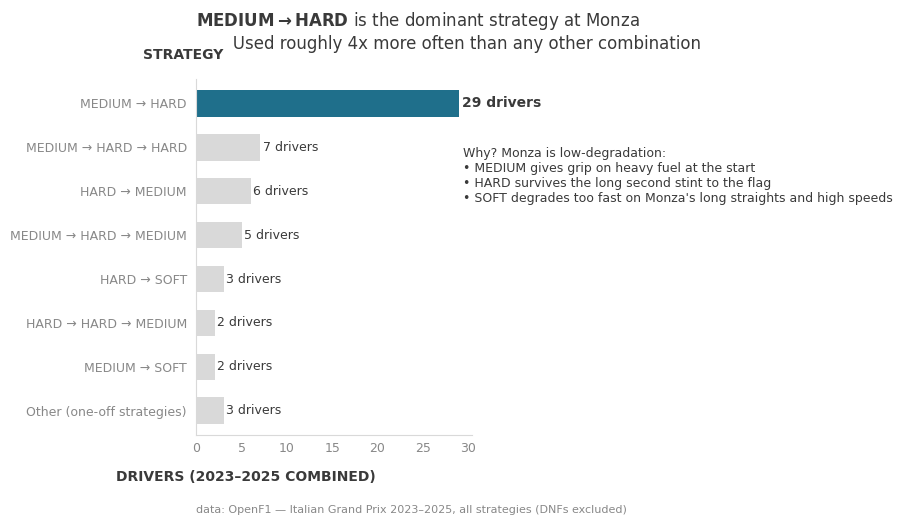

In [ ]:
# Reset to the default light theme for this chart
plt.rcdefaults()

# Ensure output dir exists relative to the notebook.
from pathlib import Path
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sum drivers per strategy across all three years (2023-2025).
totals = df_pivot.sum(axis=1).sort_values(ascending=False)

# To keep the chart legible, group very rare strategies (1 driver total) into
# an "Other" bucket. They're still represented; they just don't each get a row.
main = totals[totals > 1]
other_count = int(totals[totals == 1].sum())
if other_count > 0:
    main = pd.concat([main, pd.Series({"Other (one-off strategies)": other_count})])

# Highlight the dominant strategy by *position* (top bar after sort),
# not by hardcoded name. Falls back gracefully if MEDIUM → HARD ever isn't #1.
TARGET = "MEDIUM → HARD"
colors = [GRAY_1] * len(main)
if TARGET in main.index:
    colors[list(main.index).index(TARGET)] = BLUE_1
else:
    # Whatever the dominant strategy is, highlight it.
    colors[0] = BLUE_1

ax = main.plot(
    kind="barh", figsize=(9, 5.5), width=0.6, color=colors
)

# Largest bar on top
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_2, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("DRIVERS (2023–2025 COMBINED)", color=GRAY_3, fontweight="bold")
ax.set_ylabel("STRATEGY", rotation=0, color=GRAY_3, fontweight="bold")

# Compute the actual ratio so the title matches the data.
mh_total = int(totals.get(TARGET, totals.iloc[0]))
next_total = int(main.iloc[1]) if len(main) > 1 else 0
ratio = mh_total / next_total if next_total else 0

# Title carries the headline finding; LaTeX \bf renders the strategy name in bold.
ax.set_title(
    r"$\bf{MEDIUM \to HARD}$ is the dominant strategy at Monza"
    + f"\n       Used roughly {ratio:.0f}x more often than any other combination",
    pad=22, color=GRAY_3, loc="left",
)

ax.xaxis.set_label_coords(0.18, -0.10)
ax.yaxis.set_label_coords(-0.05, 1.05)

# Label every bar with its driver count
for i, (strategy, count) in enumerate(main.items()):
    is_target = strategy == TARGET
    ax.annotate(
        xy=(count + 0.3, i),
        text=f"{int(count)} drivers",
        fontsize=10 if is_target else 9,
        color=GRAY_3,
        fontweight="bold" if is_target else "normal",
        va="center",
    )

# 'Why?' annotation — explains the pattern instead of just showing it
ax.annotate(
    xy=(mh_total + 0.5, 1.0),
    text=(
        "Why? Monza is low-degradation:\n"
        "• MEDIUM gives grip on heavy fuel at the start\n"
        "• HARD survives the long second stint to the flag\n"
        "• SOFT degrades too fast on Monza's long straights and high speeds"
    ),
    fontsize=9, color=GRAY_3, va="top",
)

# Source footer
ax.annotate(
    xy=(0, -0.22),
    xycoords="axes fraction",
    text="data: OpenF1 — Italian Grand Prix 2023–2025, all strategies (DNFs excluded)",
    fontsize=8, color=GRAY_2,
)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pitstops_strategy_dominance.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
print("Done!")

Done!
